In [1]:
import numpy as np
import os
import pickle
import shutil
from tensorflow.keras import applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout, Flatten, Dense, GlobalAveragePooling2D
from sklearn.model_selection import train_test_split
import cv2
from tensorflow.keras.models import load_model
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from IPython.display import Video
from tqdm import tqdm

I0000 00:00:1776535027.950378   10249 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776535027.956384   10249 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776535028.700136   10249 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776535030.386939   10249 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# Configuration
source_root = 'cropped_img'
base_dir = 'prepared_data'
# Clean up existing prepared_data if any
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Your new 2 classes
classes = ['Reserved', 'Unreserved']

# Create destination folders
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Process Files
for cls in classes:
    src_path = os.path.join(source_root, cls)

    # Check if folder exists
    if not os.path.exists(src_path):
        print(f"Warning: Folder {src_path} not found. Skipping...")
        continue

    # List all images
    files = [f for f in os.listdir(src_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(files) == 0:
        print(f"No images found in {src_path}")
        continue

    # Split 80% train, 20% test
    train_files, test_files = train_test_split(files, test_size=0.20, random_state=42)

    # Helper function to copy
    def copy_files(file_list, split_name):
        for f in file_list:
            src = os.path.join(src_path, f)
            dst = os.path.join(base_dir, split_name, cls, f)
            shutil.copy(src, dst)

    copy_files(train_files, 'train')
    copy_files(test_files, 'test')

print(f"Data reorganized successfully! Classes: {classes}")

Data reorganized successfully! Classes: ['Reserved', 'Unreserved']


In [3]:
img_width, img_height = 48, 48
train_data_dir = 'prepared_data/train'
validation_data_dir = 'prepared_data/test'
batch_size = 32
epochs = 15

# Data Augmentation helps "equilibrate" the learning process
# by creating variations of minority classes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    interpolation='lanczos'
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    interpolation='lanczos'
)

# This handles the "equilibrated" weight calculation automatically
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
train_class_weights = dict(enumerate(class_weights))

print(f"Weights to balance classes: {train_class_weights}")

Found 398 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Weights to balance classes: {0: np.float64(0.796), 1: np.float64(1.3445945945945945)}


In [4]:
base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# 2. Freeze the layers (don't retrain the basic shapes)
for layer in base_model.layers:
    layer.trainable = False

# 3. Add your own "head" for your specific classes
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


E0000 00:00:1776535049.769803   10249 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776535049.770164   10383 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776535049.790174   10249 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [6]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    class_weight=train_class_weights
)

model.save('parking_model_v1.h5')

Epoch 1/15


I0000 00:00:1776535056.308097   10249 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 216ms/step - accuracy: 0.8492 - loss: 0.3815 - val_accuracy: 0.9800 - val_loss: 0.1214
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - accuracy: 0.9724 - loss: 0.1121 - val_accuracy: 0.9900 - val_loss: 0.0483
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9824 - loss: 0.0613 - val_accuracy: 0.9900 - val_loss: 0.0518
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.9925 - loss: 0.0376 - val_accuracy: 0.9900 - val_loss: 0.0415
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.9899 - loss: 0.0411 - val_accuracy: 0.9900 - val_loss: 0.0410
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.9925 - loss: 0.0260 - val_accuracy: 0.9900 - val_loss: 0.0403
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accuracy: 0.9950 - loss: 0.0271 - val_accuracy: 0.9900 - val_loss: 0.0367
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.9975 - loss: 0.0188 - val_accuracy: 0.9900 - val_

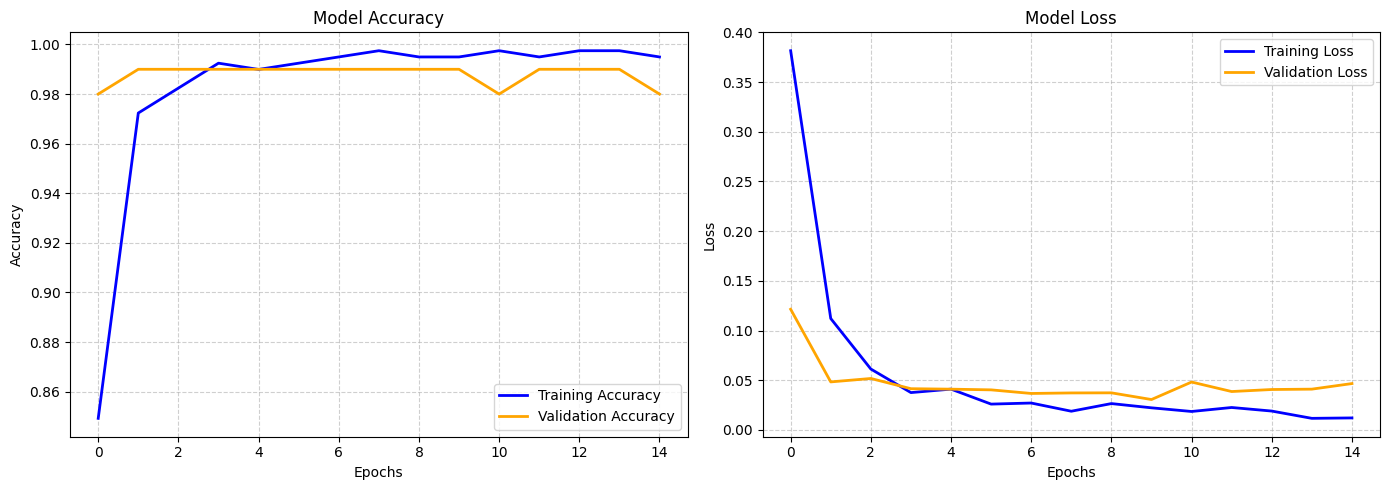

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Create the plots
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Save and show
plt.tight_layout()

In [8]:
# 1. LOAD DATA & MODEL
model = load_model('parking_model_v1.h5')
with open('./car_position_parking.pkl', 'rb') as f:
    posList = pickle.load(f)

# Box dimensions
width, height = 40, 65

# 2. VIDEO SETUP
cap = cv2.VideoCapture('parking.mp4')
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('processed.mp4', fourcc, fps, (frame_w, frame_h))

# --- CONFIGURATION ---
SKIP_FRAMES = 2
last_results = []

def checkParkingSpace(img):
    img_crops = []
    active_positions = []

    for pos in posList:
        x, y = pos
        imgCrop = img[y:y + height, x:x + width]

        if imgCrop.size == 0 or imgCrop.shape[0] < 5 or imgCrop.shape[1] < 5:
            continue

        imgResize = cv2.resize(imgCrop, (48, 48), interpolation=cv2.INTER_LANCZOS4)
        imgNormalized = imgResize.astype('float32') / 255.0
        img_crops.append(imgNormalized)
        active_positions.append(pos)

    if len(img_crops) > 0:
        batch_array = np.array(img_crops)
        predictions = model.predict(batch_array, verbose=0)
        class_indices = np.argmax(predictions, axis=1)
        return list(zip(active_positions, class_indices))
    return []

# 3. MAIN PROCESSING LOOP (Full Video)
for frame_idx in tqdm(range(total_frames), desc="Processing Full Video"):
    success, frame = cap.read()
    if not success:
        break

    # Update AI results every SKIP_FRAMES
    if frame_idx % SKIP_FRAMES == 0:
        last_results = checkParkingSpace(frame)

    # DRAWING LOGIC (3 CLASSES)
    for pos, class_idx in last_results:
        x, y = pos

        # 0: Reserved, 1: Unreserved
        if class_idx == 0:   # Reserved
            color, thickness = (0, 0, 255), 2  # Red
        else:                # Unreserved (1)
            color, thickness = (0, 255, 0), 2  # Green

        cv2.rectangle(frame, (x, y), (x + width, y + height), color, thickness)

    out.write(frame)

cap.release()
out.release()

Processing Full Video: 100%|██████████| 701/701 [15:58<00:00,  1.37s/it]
